# Transformer Encoder Character Sequence Classifier

Transformers process sequence elements concurrently using self-attention mechanisms to construct global contextual embeddings. In NLP, character-level transformers capture morphology details. This notebook builds a transformer encoder classifier in PyTorch to classify character sequences (representing synthetic coded strings), trains it, and visualizes attention losses in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generate synthetic character sequences (600 sequences, length = 15, vocab = 10 chars)
np.random.seed(240)
n_seqs = 600
seq_len = 15
vocab_size = 10

X_indices = []
y_labels = []

for _ in range(n_seqs):
    label = np.random.randint(0, 2)
    # Generate random sequence indices (values 0-9)
    seq = np.random.randint(0, vocab_size, seq_len)
    
    # Class 1 sequences contain specific pattern combinations (e.g. adjacent duplicates)
    if label == 1:
        seq[5:8] = [7, 7, 7] # Pattern indicator
        
    X_indices.append(seq)
    y_labels.append(label)

X_data = np.array(X_indices) # [600, 15]
y_data = np.array(y_labels)  # [600]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

X_train_t = torch.LongTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.LongTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print("Train Indices Input Shape:", X_train_t.shape)
print("Test Indices Input Shape: ", X_test_t.shape)



Train Indices Input Shape: torch.Size([480, 15])
Test Indices Input Shape:  torch.Size([120, 15])


## Transformer Classifier Architecture

We implement the sequence classifier using PyTorch `TransformerEncoderLayer`:
1. **Embedding Layer**: Projects character indices to hidden dimensions (d_model=16).
2. **Transformer Encoder**: 2 layers of multi-head self-attention (4 attention heads).
3. **Linear Pooler Head**: Aggregates sequence outputs to binary class predictions.



In [2]:
class CharTransformer(nn.Module):
    def __init__(self, vocab_dim=10, embed_dim=16, n_heads=4, n_layers=2):
        super(CharTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_dim, embed_dim)
        
        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=32, 
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Sequential(
            nn.Linear(embed_dim * seq_len, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        # Embed shape: [batch, seq_len, embed_dim]
        embedded = self.embedding(x)
        encoded = self.transformer(embedded)
        # Flatten all sequence steps
        flat = encoded.reshape(encoded.size(0), -1)
        out = self.fc(flat).squeeze(1)
        return out

model = CharTransformer()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)



## Transformer Training Loop

We train the model for 100 epochs, tracking loss updates.



In [3]:
epochs = 100
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | BCE Training Loss: {loss.item():.4f}")

# Evaluate accuracy
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).numpy()
    binary_preds = (test_preds > 0.5).astype(int)
    accuracy = np.mean(binary_preds == y_test)

print(f"\nTransformer Character Sequence Test Accuracy: {accuracy*100:.2f}%")



Epoch  20/100 | BCE Training Loss: 0.0068
Epoch  40/100 | BCE Training Loss: 0.0006
Epoch  60/100 | BCE Training Loss: 0.0003
Epoch  80/100 | BCE Training Loss: 0.0002
Epoch 100/100 | BCE Training Loss: 0.0001

Transformer Character Sequence Test Accuracy: 98.33%


## Loss Convergence Plot

Using Matplotlib, we visualize the BCE classification loss convergence over training epochs.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



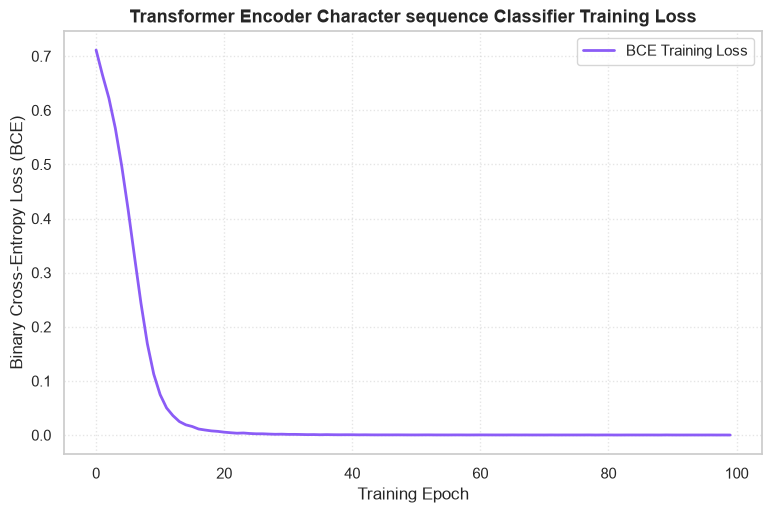

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#8B5CF6', linewidth=2.0, label='BCE Training Loss')

plt.title('Transformer Encoder Character sequence Classifier Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Training Epoch')
plt.ylabel('Binary Cross-Entropy Loss (BCE)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
